In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
#Load the dataset
df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Check dataset dimensions and column names
df.shape

(101766, 50)

In [4]:
print("\nColumn Names:\n", df.columns.tolist())


Column Names:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [5]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
# Replace '?' with NaN to properly identify missing values
df.replace('?', np.nan, inplace = True)



# Show only columns with missing values
print(df.isnull().sum()[df.isnull().sum()>0])

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


In [8]:
# Drop columns with more than 95% missing values — not useful for analysis

df.drop(columns=['weight','payer_code','max_glu_serum'], inplace = True)
print("Remaining Columns:", df.shape[1])

Remaining Columns: 47


In [11]:
# Check the distribution of our traget variable

print(df['readmitted'].value_counts())

print("\nPercentage:\n", df['readmitted'].value_counts(normalize = True)*100)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentage:
 readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


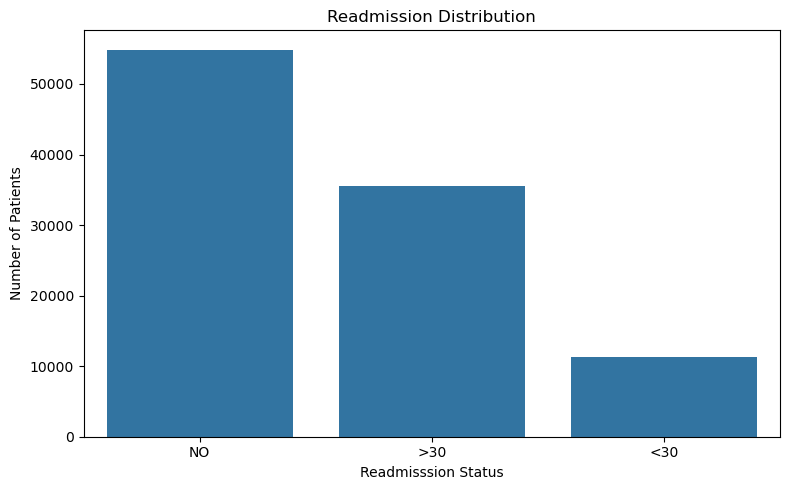

In [13]:
# Visualize readmission distribution
plt.figure(figsize=(8,5))
sns.countplot(x='readmitted', data=df, order=['NO', '>30', '<30'])
plt.title('Readmission Distribution')
plt.xlabel('Readmisssion Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [17]:
# Create a binary target column - 1 if readmitted within 30 days, 0 otherwise
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_binary'].value_counts())

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


In [19]:
# Readmission rate by age group
age_readmission = df.groupby('age')['readmitted_binary'].mean()*100
age_readmission = age_readmission.sort_values(ascending = True)
age_readmission

age
[0-10)       1.863354
[10-20)      5.788712
[50-60)      9.666203
[40-50)     10.604027
[90-100)    11.099177
[60-70)     11.128408
[30-40)     11.231788
[70-80)     11.773055
[80-90)     12.083503
[20-30)     14.242607
Name: readmitted_binary, dtype: float64

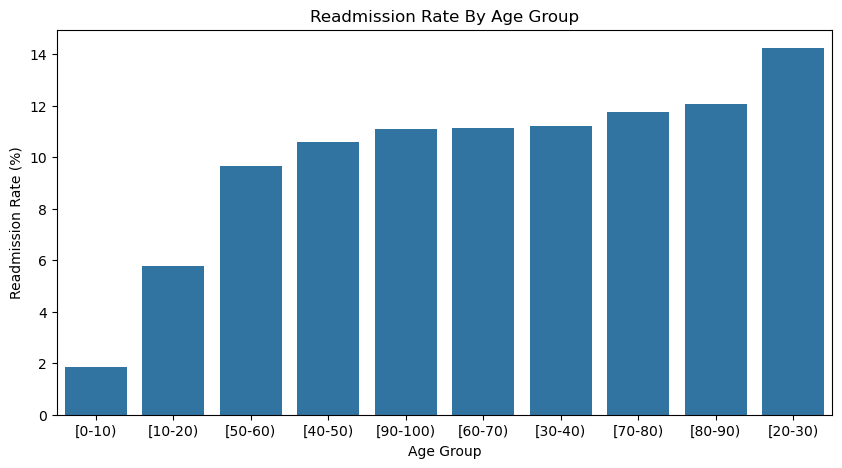

In [20]:
# Plot for Readmission rate by age group
plt.figure(figsize = (10,5))
sns.barplot(x=age_readmission.index, y=age_readmission.values)
plt.title('Readmission Rate By Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout
plt.show()

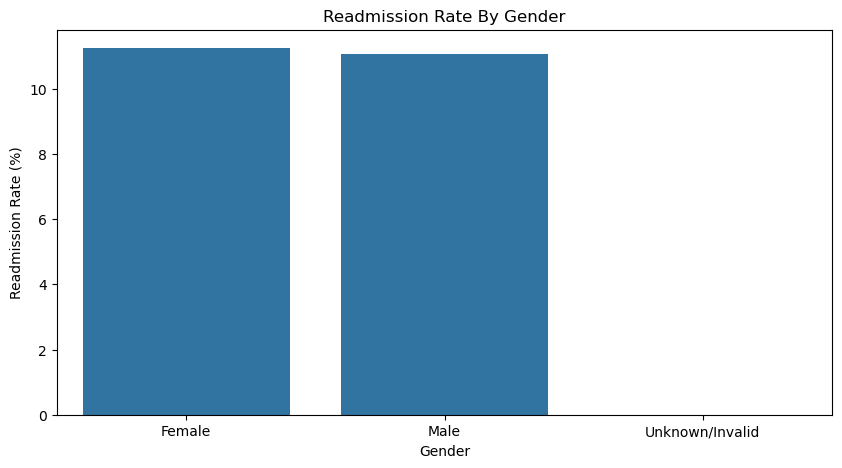

In [23]:
# Readmission rate by genger
gender_readmission = df.groupby('gender')['readmitted_binary'].mean() * 100

plt.figure(figsize = (10,5))
sns.barplot(x=gender_readmission.index, y=gender_readmission.values)
plt.title('Readmission Rate By Gender')
plt.xlabel('Gender')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout
plt.show()

In [26]:
# Average hospital stay by readmission status
stay_readmission = df.groupby('readmitted_binary')['time_in_hospital'].mean()
stay_readmission

readmitted_binary
0    4.349224
1    4.768249
Name: time_in_hospital, dtype: float64

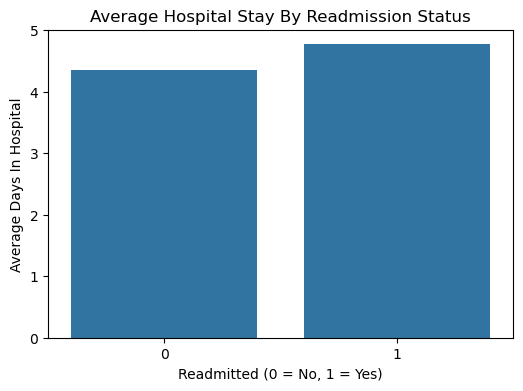

In [27]:
# Plot
plt.figure(figsize = (6,4))
sns.barplot(x=stay_readmission.index, y=stay_readmission.values)
plt.title('Average Hospital Stay By Readmission Status')
plt.xlabel('Readmitted (0 = No, 1 = Yes)')
plt.ylabel('Average Days In Hospital')
plt.tight_layout
plt.show()

In [28]:
# Average medication count by readmission status
med_readmission = df.groupby('readmitted_binary')['num_medications'].mean()
med_readmission

readmitted_binary
0    15.911137
1    16.903143
Name: num_medications, dtype: float64

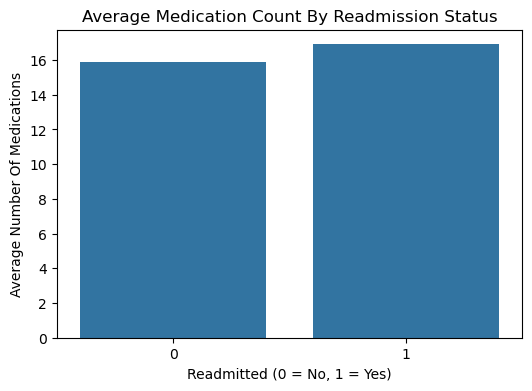

In [30]:
#plot
plt.figure(figsize = (6,4))
sns.barplot(x=med_readmission.index,y=med_readmission.values)
plt.title('Average Medication Count By Readmission Status')
plt.xlabel('Readmitted (0 = No, 1 = Yes)')
plt.ylabel('Average Number Of Medications')
plt.tight_layout
plt.show()

In [34]:
# Readmission rate by insulin status
insulin_readmission = df.groupby('insulin')['readmitted_binary'].mean()*100
insulin_readmission

insulin
Down      13.897528
No        10.037355
Steady    11.128400
Up        12.990456
Name: readmitted_binary, dtype: float64

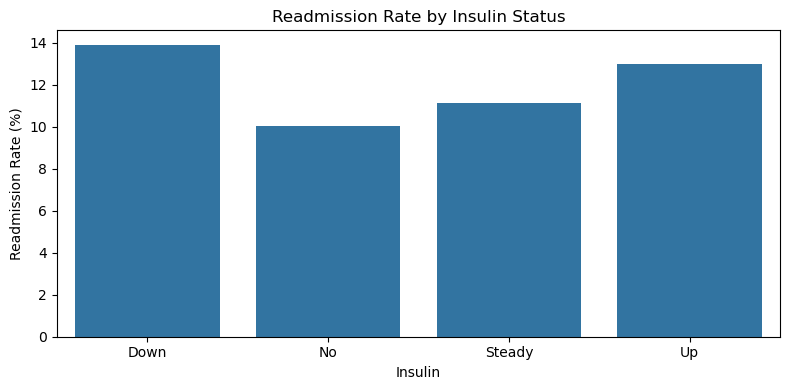

In [35]:
plt.figure(figsize=(8, 4))
sns.barplot(x=insulin_readmission.index, y=insulin_readmission.values)
plt.title('Readmission Rate by Insulin Status')
plt.xlabel('Insulin')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

In [37]:
diag_readmission = df.groupby('number_diagnoses')['readmitted_binary'].mean()*100
diag_readmission

number_diagnoses
1      5.936073
2      6.060606
3      7.372134
4      8.253567
5      9.154744
6     10.412361
7     10.766862
8     11.812359
9     12.380240
10    17.647059
11    27.272727
12    11.111111
13    18.750000
14    14.285714
15    20.000000
16     8.888889
Name: readmitted_binary, dtype: float64

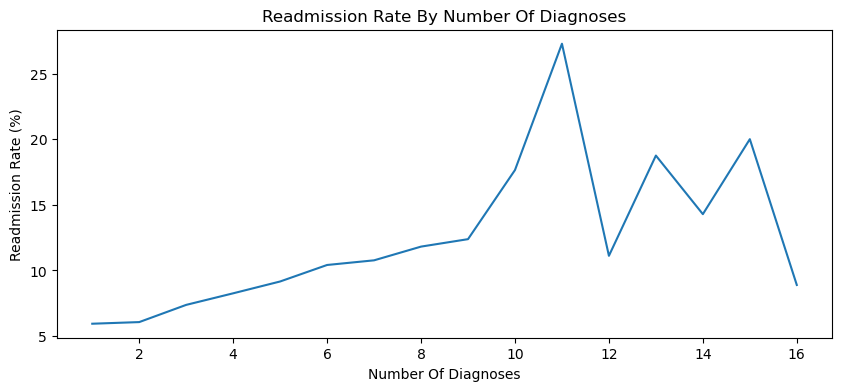

In [36]:
# Readmission rate by number of diagnoses
diag_readmission = df.groupby('number_diagnoses')['readmitted_binary'].mean()*100
diag_readmission

plt.figure(figsize=(10,4))
sns.lineplot(x=diag_readmission.index, y=diag_readmission.values)
plt.title('Readmission Rate By Number Of Diagnoses')
plt.xlabel('Number Of Diagnoses')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout
plt.show()

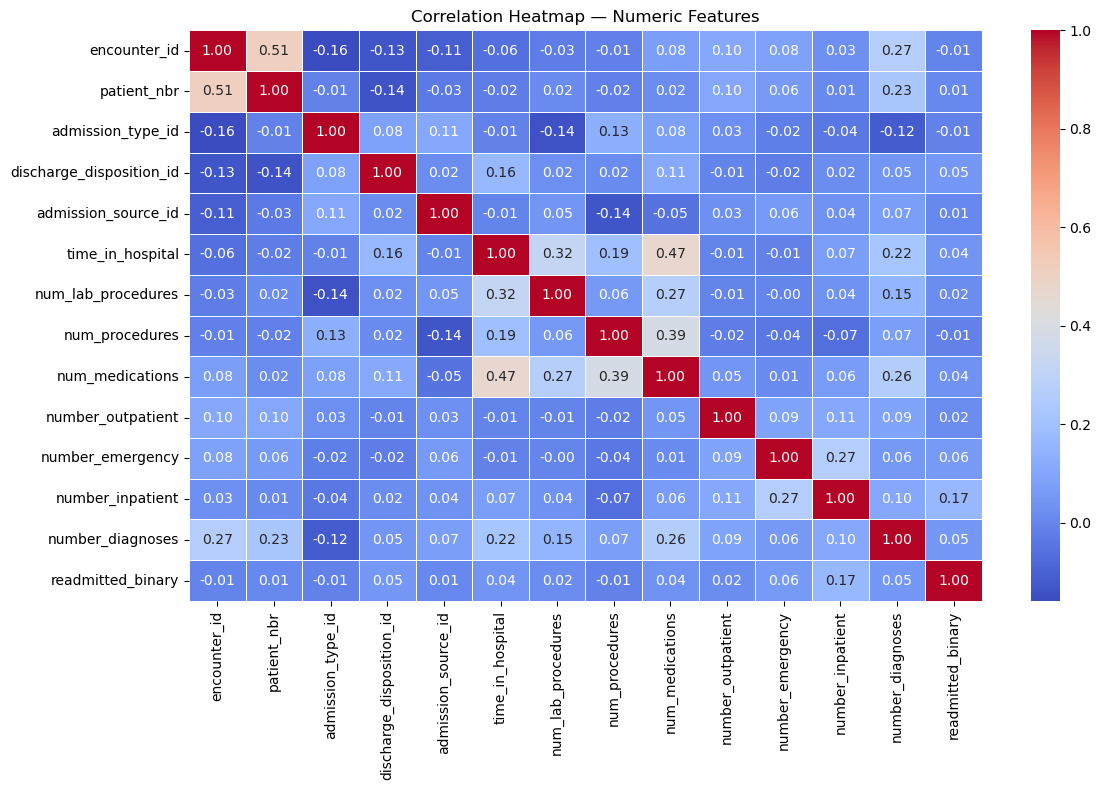

In [38]:
# Correlation heatmap of numeric columns
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## Key Findings — Diabetes Readmission EDA

### Dataset
- 101,766 patient records, 50 features, 130 US hospitals (1999–2008)
- Target: 30-day readmission (`<30`) — 11.16% of patients

### Missing Values
- `weight`, `payer_code`, `max_glu_serum` dropped — 95%+ missing
- `A1Cresult` and `medical_specialty` retained despite high missingness — clinically important

### Key Findings
1. **Age** — 20–30 age group has highest early readmission rate — counterintuitive, likely lifestyle-driven
2. **Gender** — not a significant predictor — rates nearly equal across male and female
3. **Hospital Stay** — readmitted patients average 4.77 days vs 4.5 days — longer stays signal severity
4. **Medications** — readmitted patients average 1 extra medication — higher complexity
5. **Insulin** — dose changes (Up or Down) show higher readmission than Steady — instability is the risk signal
6. **Diagnoses** — readmission rate doubles from 1 diagnosis (6%) to 9 diagnoses (12%)
7. **Correlation** — `number_inpatient` is the strongest numeric predictor of readmission (0.17)

### Business Insight
No single feature predicts readmission strongly — this is a multi-factor problem best solved with ML modeling.

### Tools Used
- Python, Pandas, NumPy, Matplotlib, Seaborn
- Jupyter Notebook